<a href="https://colab.research.google.com/github/Hemanshu-ml-analytics/Detect_mask1_/blob/main/Face_Mask_Detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
os.environ['KAGGLE_API_TOKEN']='KGAT_e66f49b5d8f026e0c588ac62d82b8fdd'

In [2]:
!pip install -q kaggle

In [3]:
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
100% 163M/163M [00:01<00:00, 136MB/s]



In [4]:
!unzip face-mask-dataset -d face-mask-dataset

Streaming output truncated to the last 5000 lines.
  inflating: face-mask-dataset/data/with_mask/with_mask_3297.jpg  
  inflating: face-mask-dataset/data/with_mask/with_mask_3298.jpg  
  inflating: face-mask-dataset/data/with_mask/with_mask_3299.jpg  
  inflating: face-mask-dataset/data/with_mask/with_mask_33.jpg  
  inflating: face-mask-dataset/data/with_mask/with_mask_330.jpg  
  inflating: face-mask-dataset/data/with_mask/with_mask_3300.jpg  
  inflating: face-mask-dataset/data/with_mask/with_mask_3301.jpg  
  inflating: face-mask-dataset/data/with_mask/with_mask_3302.jpg  
  inflating: face-mask-dataset/data/with_mask/with_mask_3303.jpg  
  inflating: face-mask-dataset/data/with_mask/with_mask_3304.jpg  
  inflating: face-mask-dataset/data/with_mask/with_mask_3305.jpg  
  inflating: face-mask-dataset/data/with_mask/with_mask_3306.jpg  
  inflating: face-mask-dataset/data/with_mask/with_mask_3307.jpg  
  inflating: face-mask-dataset/data/with_mask/with_mask_3308.jpg  
  inflating: f

In [6]:
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
from PIL import Image
import numpy as np



In [7]:
# read the directories
with_mask=os.listdir("/content/face-mask-dataset/data/with_mask")
print(with_mask[0:5])
print(with_mask[-5:])

['with_mask_826.jpg', 'with_mask_3065.jpg', 'with_mask_3393.jpg', 'with_mask_1003.jpg', 'with_mask_2848.jpg']
['with_mask_1076.jpg', 'with_mask_3561.jpg', 'with_mask_505.jpg', 'with_mask_1001.jpg', 'with_mask_665.jpg']


In [7]:
without_mask=os.listdir("/content/face-mask-dataset/data/without_mask")
print(without_mask[0:5])
print(without_mask[-5:])

['without_mask_3615.jpg', 'without_mask_1957.jpg', 'without_mask_2373.jpg', 'without_mask_2314.jpg', 'without_mask_649.jpg']
['without_mask_1210.jpg', 'without_mask_2776.jpg', 'without_mask_226.jpg', 'without_mask_2287.jpg', 'without_mask_3783.jpg']


In [8]:
print("without mask images are ",len(without_mask))
print("with mask images are ",len(with_mask))

without mask images are  3828
with mask images are  3725


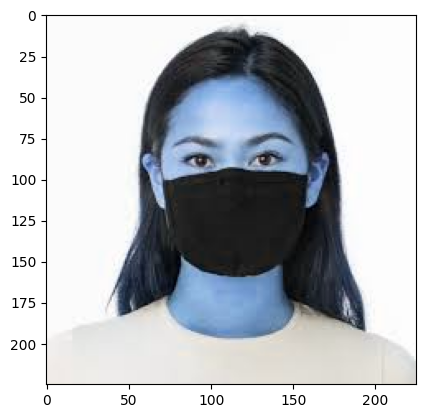

In [9]:
#check the mask section
image=cv2.imread('/content/face-mask-dataset/data/with_mask/with_mask_2136.jpg')
plt.imshow(image)

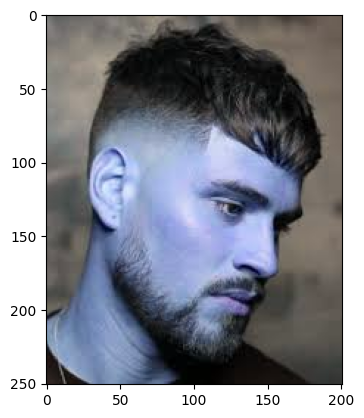

In [10]:
image1=cv2.imread('/content/face-mask-dataset/data/without_mask/without_mask_2565.jpg')
plt.imshow(image1)

In [11]:
# label assiging
with_mask_label=[1]*3725
without_mask_label=[0]*3828

print(with_mask_label[:6])
print(without_mask_label[:6])

[1, 1, 1, 1, 1, 1]
[0, 0, 0, 0, 0, 0]


In [12]:
print(image1.shape)

(251, 201, 3)


In [13]:
# image preprocessing
# for masked dataset
dataset_path="/content/face-mask-dataset/data/with_mask/"
data=[]

for image_file in with_mask:
  image=Image.open(dataset_path + image_file )
  resized=image.resize((128,128))
  resized1=resized.convert('RGB')
  array1=np.array(resized1)
  data.append(array1)
print(data[0].shape)


#image preprocessing
#for without mask

dataset='/content/face-mask-dataset/data/without_mask/'

for image_file in without_mask:
  image=Image.open(dataset + image_file)
  resized=image.resize((128,128))
  resized1=resized.convert('RGB')
  array1=np.array(resized1)
  data.append(array1)
print(data[0].shape)


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


(128, 128, 3)
(128, 128, 3)


In [14]:
labels=with_mask_label + without_mask_label
x=np.array(data)
y=np.array(labels)


In [15]:
#train test split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [16]:
# scalling the image
scalled_xtrain=x_train/255
scalled_xtest=x_test/255

In [17]:
scalled_xtest[0]

array([[[0.85490196, 0.85098039, 0.84313725],
        [0.85490196, 0.85098039, 0.84313725],
        [0.85882353, 0.85490196, 0.84705882],
        ...,
        [0.85882353, 0.85490196, 0.84705882],
        [0.85882353, 0.85490196, 0.84705882],
        [0.85882353, 0.85490196, 0.84705882]],

       [[0.85490196, 0.85098039, 0.84313725],
        [0.85490196, 0.85098039, 0.84313725],
        [0.85490196, 0.85098039, 0.84313725],
        ...,
        [0.85882353, 0.85490196, 0.84705882],
        [0.85882353, 0.85490196, 0.84705882],
        [0.85882353, 0.85490196, 0.84705882]],

       [[0.85490196, 0.85098039, 0.84313725],
        [0.85490196, 0.85098039, 0.84313725],
        [0.85490196, 0.85098039, 0.84313725],
        ...,
        [0.8627451 , 0.85882353, 0.85098039],
        [0.8627451 , 0.85882353, 0.85098039],
        [0.8627451 , 0.85882353, 0.85098039]],

       ...,

       [[0.84313725, 0.83921569, 0.83137255],
        [0.84313725, 0.83921569, 0.83137255],
        [0.84313725, 0

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,Dense,Flatten,MaxPooling2D,Dropout

model=Sequential()
model.add(Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))


model.add(Dense(2, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [20]:
model.fit(scalled_xtrain,y_train,epochs=10)

Epoch 1/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.7949 - loss: 0.4948
Epoch 2/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8954 - loss: 0.2764
Epoch 3/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9143 - loss: 0.2197
Epoch 4/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9265 - loss: 0.1942
Epoch 5/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9379 - loss: 0.1715
Epoch 6/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9548 - loss: 0.1196
Epoch 7/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9535 - loss: 0.1198
Epoch 8/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9618 - loss: 0.1055
Epoch 9/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9657 - loss: 0.0888
Epoch 10/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9628 - loss: 0.0936


In [23]:
loss,accuracy=model.evaluate(scalled_xtest,y_test)


48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9312 - loss: 0.2010


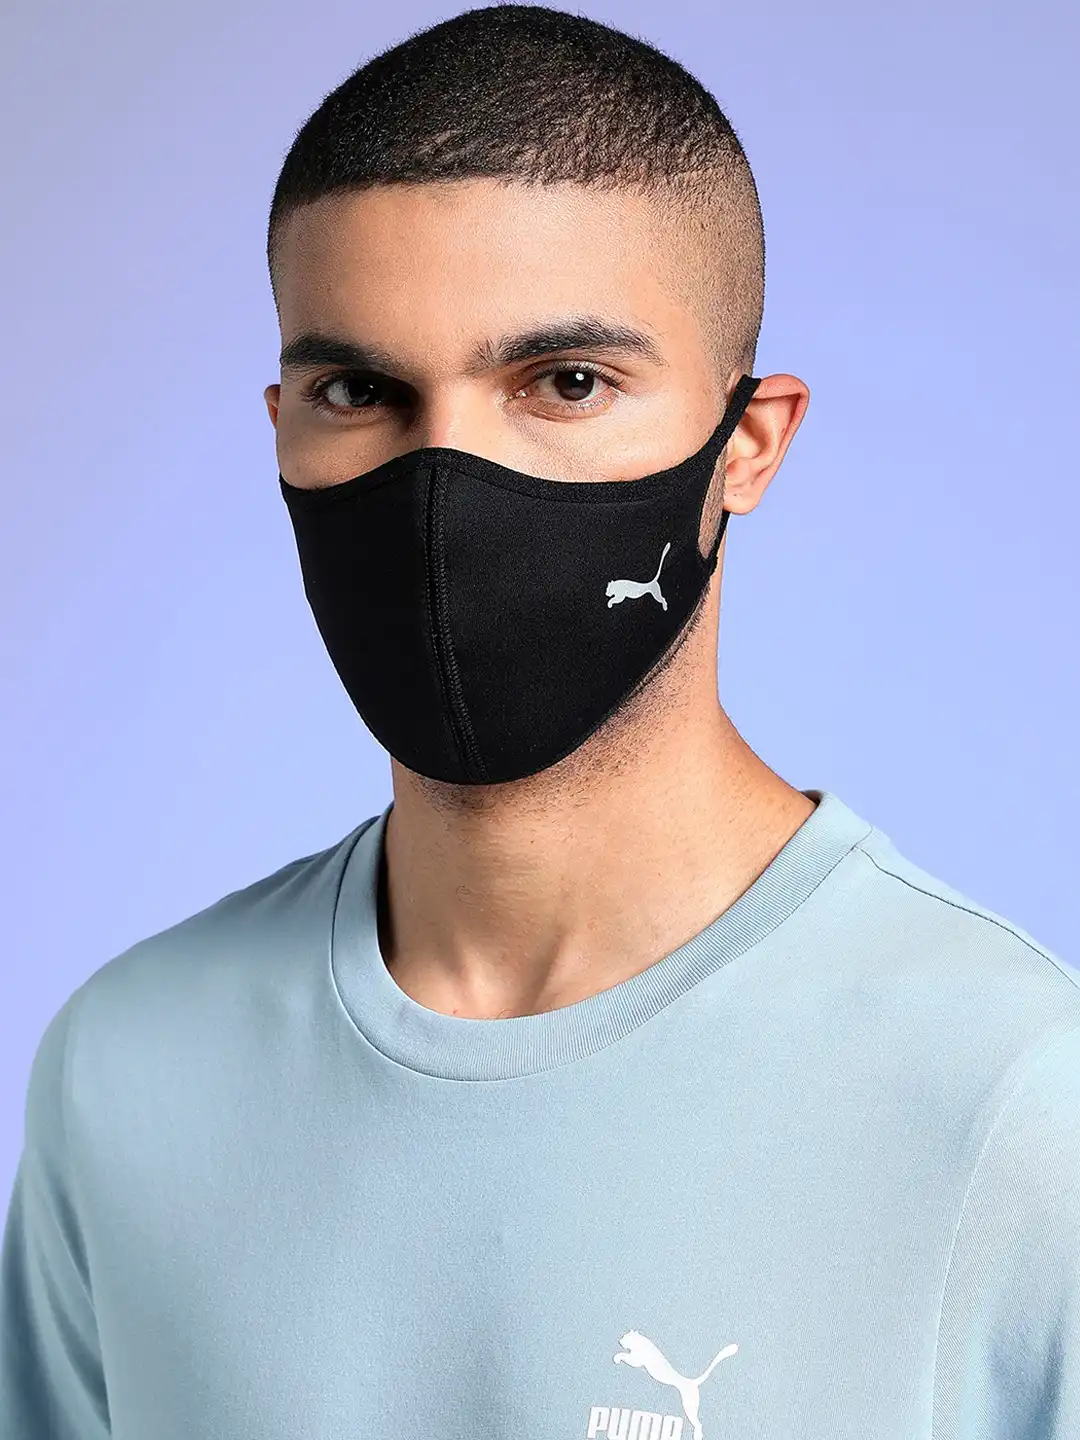

In [67]:
from google.colab.patches import cv2_imshow
#testing

person1=cv2.imread('/content/mask1.jpg')
cv2_imshow(person1)


In [69]:
person1='/content/mask1.jpg'
image=Image.open(person1)

# resize the image
resized = image.resize((128,128))
convert=resized.convert('RGB')
arr1=np.array(convert)

# scalled
scalled_image= arr1/255

# reshape
image=np.reshape(scalled_image,[1,128,128,3])

# prediction

prediction=model.predict(image)
prediction=np.argmax(prediction)

if prediction ==1:
   print( 'YES, he weared the mask')

else:
  print("Not he not weared the mask")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
YES, he weared the mask
